# PS8 — Problem 5: Threshold Delta-Hedger + Engine

**Task.** *"Implement a delta-hedger triggering when `|Δ| > 0.1 BTC`, integrate it
with the Week-5 engine on one week of data, and report hedging cost, risk
reduction, and the quoting/hedging interaction."*

**What we build.** The Week-5 event-driven engine
(`code/week05_engine/backtest.py`) carried over to an *options* book and wired to
a delta-hedger:

1. A small near-ATM BTC option book is **market-made by replaying the real
   Coincall trade tape** — each printed trade at a tracked strike fills the maker
   on the passive side (aggressor buy ⇒ maker short; aggressor sell ⇒ maker long).
2. The book's Greeks are aggregated to a **net delta** (the vector inventory of
   Problem 8.1, reduced to its delta). Deltas come from the repo's **PyTorch
   autograd** Black-76 pricer (`code/week06_vol_surface/bs_greeks.py`).
3. Whenever `|net Δ| > threshold`, a **BTC perp hedge** is rebalanced with
   `threshold_hedge` from `code/week08_hedging/multi_greek_hedge.py`.

We run the base **0.1-BTC** case hedged vs. unhedged, then **sweep the trigger**
to trace the cost-vs-risk-reduction frontier, and close on the quoting/hedging
interaction.

> **Data.** One week, **2026-06-16 → 06-22**, of recorded Coincall captures on the
> external drive `/Volumes/SEAGATE/Crypto/Coincall_OB/` (futures L2, option trade
> tape, option top-of-book snapshots). The drive must be mounted to run this
> notebook. All heavy lifting lives in `helpers_hedge/` (see
> `coincall_replay.py` and `hedge_engine.py`).

In [1]:
import sys, pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = pathlib.Path(".").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from helpers_hedge import hedge_engine as he
from helpers_hedge import coincall_replay as cr

FIG_DIR = ROOT / "figures"; FIG_DIR.mkdir(exist_ok=True)
OUT_DIR = ROOT / "output"; OUT_DIR.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
WOLF = "#CC0000"  # NC State Wolfpack red

cfg = he.HedgeConfig()          # threshold=0.1 BTC, fee=2.5 bps, 2026-06-16..06-22
cfg

HedgeConfig(threshold=0.1, fee_bps=2.5, contract_size=1.0, qty_cap=None, start='2026-06-16', end='2026-06-22')

## 1 · Data, book, and the replayed fills

We load the futures top-of-book path (the underlying mark **and** the perp we
hedge on), the option trade tape, and pick a small book: the five most-traded
strikes of the most active expiry that *survives the whole week* (so no tracked
contract expires mid-run). The trade tape carries two clocks — a live-print
stream and stale backfilled duplicates — and we keep only genuinely live prints
on the capture clock (see `load_trade_tape`).

In [2]:
fut, tape, book, iv_map, ev = he.load_all(cfg)

exp = cr._parse_symbol(book[0])["expiry"].strftime("%d %b %Y")
fills = tape[tape["symbol"].isin(book)]
print(f"futures marks : {len(fut):>6,}  (mid {fut['mid'].min():,.0f}..{fut['mid'].max():,.0f}, "
      f"median half-spread ${fut['half_spread'].median():.2f})")
print(f"book expiry   : {exp}")
for s in book:
    n = int((fills['symbol'] == s).sum())
    print(f"   {s:26s}  {n:3d} fills")
print(f"events        : {len(ev):>6,}  ({int(ev['is_fill'].sum())} replayed fills)")
print(f"maker sides   : buys {int((fills['trade_side']==cr.AGGRESSOR_SELL).sum())}, "
      f"sells {int((fills['trade_side']==cr.AGGRESSOR_BUY).sum())}")

futures marks : 10,077  (mid 62,364..67,021, median half-spread $5.10)
book expiry   : 31 Jul 2026
   BTCUSD-31JUL26-62000-P       80 fills
   BTCUSD-31JUL26-60000-P       27 fills
   BTCUSD-31JUL26-59000-P       27 fills
   BTCUSD-31JUL26-67000-C       26 fills
   BTCUSD-31JUL26-68000-C       22 fills
events        : 10,259  (182 replayed fills)
maker sides   : buys 133, sells 49


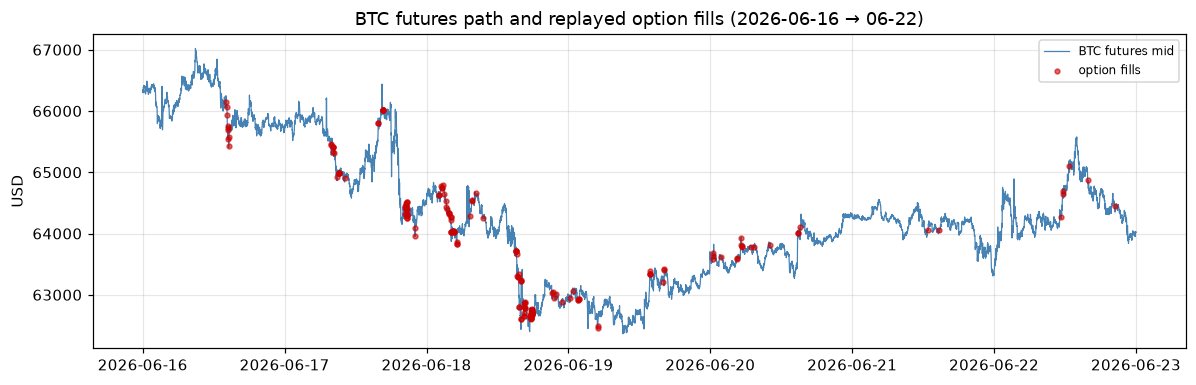

In [3]:
# Underlying path over the week, with the book's fills overlaid at the futures mid
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(fut["ts"], fut["mid"], color="steelblue", lw=0.8, label="BTC futures mid")
f_at = pd.merge_asof(fills[["ts"]].sort_values("ts"), fut[["ts", "mid"]],
                     on="ts", direction="nearest")
ax.scatter(f_at["ts"], f_at["mid"], s=10, color=WOLF, alpha=0.6,
           label="option fills", zorder=3)
ax.set_title("BTC futures path and replayed option fills (2026-06-16 → 06-22)")
ax.set_ylabel("USD"); ax.legend(loc="upper right", fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "ps8_p5_underlying_fills.png", bbox_inches="tight")
plt.show()

## 2 · Engine + hedger — base case at the 0.1-BTC trigger

`build_event_frame` walks the merged (futures-mark + fill) timeline **once**,
replaying fills and marking the book; the whole book's net delta is one autograd
backward per event. `run_hedge` then replays that net-delta path through
`threshold_hedge`, accounting P&L. `threshold=None` is the unhedged baseline.

In [4]:
base = he.run_hedge(ev, cfg.threshold, cfg)
unh  = he.run_hedge(ev, None, cfg)
mb, mu = base["metrics"], unh["metrics"]

rows = ["total_pnl", "spread_pnl", "inventory_pnl", "hedge_pnl", "hedge_cost",
        "rms_option_delta", "rms_total_delta", "delta_risk_reduction",
        "pnl_vol", "max_drawdown", "n_hedges", "perp_turnover_btc"]
cmp = pd.DataFrame({"unhedged": [mu.get(k, np.nan) for k in rows],
                    "hedged @0.1": [mb.get(k, np.nan) for k in rows]}, index=rows)
print(cmp.round(3).to_string())
print(f"\nattribution residual (should be ~0): {mb['attribution_residual']:.2e}")

                      unhedged  hedged @0.1
total_pnl              357.247     -429.512
spread_pnl             303.673      303.673
inventory_pnl           53.574       53.574
hedge_pnl                0.000     -233.556
hedge_cost               0.000      553.203
rms_option_delta         1.460        1.460
rms_total_delta          1.460        0.041
delta_risk_reduction     0.000        0.972
pnl_vol               7929.867     6112.573
max_drawdown         -5099.237    -2547.458
n_hedges                 0.000       83.000
perp_turnover_btc        0.000       14.870

attribution residual (should be ~0): 0.00e+00


**Reading the base case.** Market-making the book earns a positive gross
edge (`spread_pnl`), but leaves a **directional delta inventory** (`rms_option_delta`
≈ 1.5 BTC) that swings P&L with BTC. The 0.1-BTC hedge collapses residual delta to
`rms_total_delta` ≈ 0.04 BTC — a **~97% reduction** — and materially cuts both P&L
volatility and max drawdown. The price is `hedge_cost` (perp spread + fee) plus the
hedge's own mark P&L.

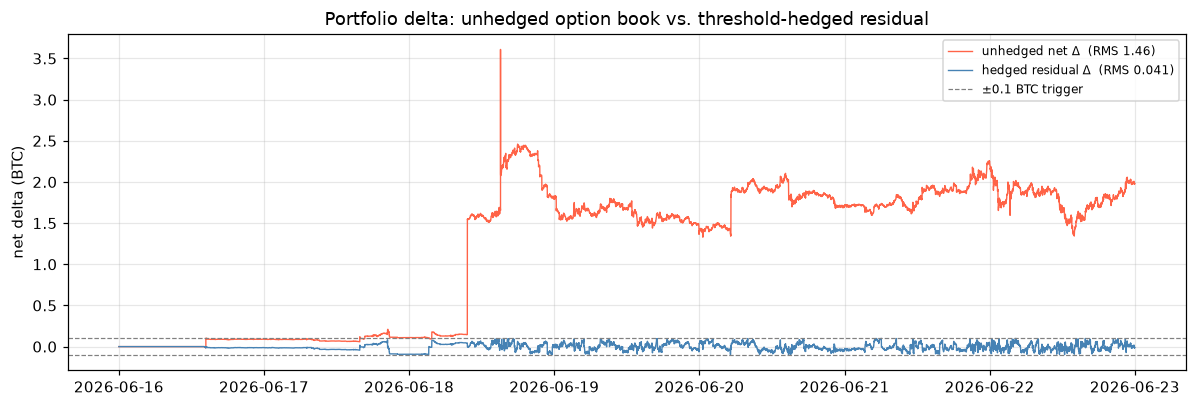

In [5]:
# Net delta path: unhedged (option book) vs hedged (residual after perp)
sb, su = base["series"], unh["series"]
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(su["ts"], su["net_option_delta"], color="tomato", lw=0.9,
        label=f"unhedged net Δ  (RMS {mu['rms_option_delta']:.2f})")
ax.plot(sb["ts"], sb["total_delta"], color="steelblue", lw=0.9,
        label=f"hedged residual Δ  (RMS {mb['rms_total_delta']:.3f})")
ax.axhline( cfg.threshold, color="gray", ls="--", lw=0.8)
ax.axhline(-cfg.threshold, color="gray", ls="--", lw=0.8, label=f"±{cfg.threshold} BTC trigger")
ax.set_title("Portfolio delta: unhedged option book vs. threshold-hedged residual")
ax.set_ylabel("net delta (BTC)"); ax.legend(loc="upper right", fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "ps8_p5_delta_hedged_vs_unhedged.png", bbox_inches="tight")
plt.show()

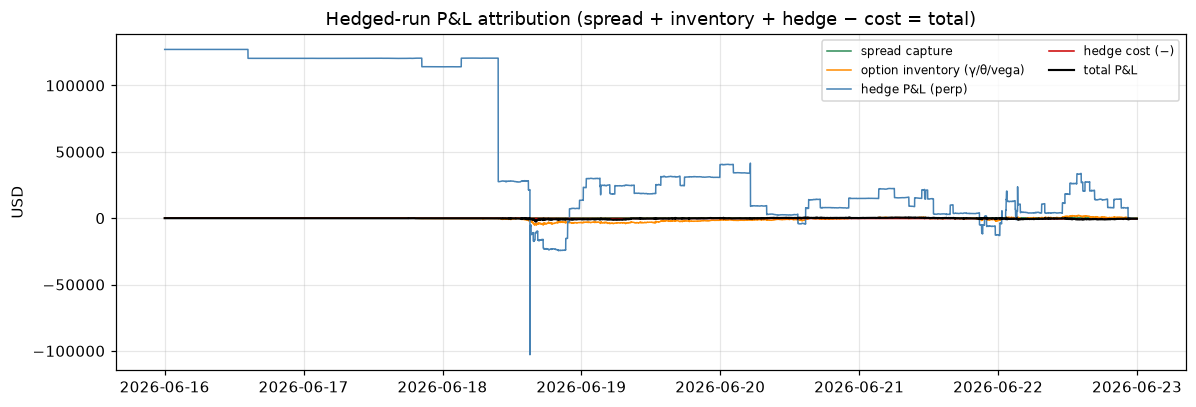

In [6]:
# P&L attribution of the hedged run: streams sum to total by construction
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(sb["ts"], sb["spread_pnl"], color="seagreen", lw=1, label="spread capture")
ax.plot(sb["ts"], sb["inventory_pnl"], color="darkorange", lw=1, label="option inventory (γ/θ/vega)")
ax.plot(sb["ts"], sb["hedge_pnl"], color="steelblue", lw=1, label="hedge P&L (perp)")
ax.plot(sb["ts"], -sb["hedge_cost"], color=WOLF, lw=1, label="hedge cost (−)")
ax.plot(sb["ts"], sb["equity"], color="black", lw=1.4, label="total P&L")
ax.set_title("Hedged-run P&L attribution (spread + inventory + hedge − cost = total)")
ax.set_ylabel("USD"); ax.legend(loc="best", fontsize=8, ncol=2)
fig.tight_layout(); fig.savefig(FIG_DIR / "ps8_p5_pnl_attribution.png", bbox_inches="tight")
plt.show()

## 3 · Threshold sweep — the cost-vs-risk-reduction frontier

The 0.1-BTC trigger is one point on a tradeoff. We sweep
`{0.02, 0.05, 0.1, 0.2, 0.5}`: a **tighter** trigger hedges more often, driving
residual delta toward zero but paying more in perp frictions.

In [7]:
THRESHOLDS = [0.02, 0.05, 0.1, 0.2, 0.5]
sweep = he.run_sweep(ev, THRESHOLDS, cfg)
sweep.to_csv(OUT_DIR / "ps8_p5_threshold_sweep.csv", index=False)

show = ["threshold", "n_hedges", "perp_turnover_btc", "hedge_cost",
        "rms_total_delta", "delta_risk_reduction", "pnl_vol", "max_drawdown", "total_pnl"]
hed = sweep[sweep["hedged"]].sort_values("threshold")
print("UNHEDGED baseline:")
print(sweep[~sweep["hedged"]][["rms_option_delta", "pnl_vol", "max_drawdown", "total_pnl"]]
      .round(2).to_string(index=False))
print("\nHEDGED sweep (tighter trigger → more hedging):")
print(hed[show].round(3).to_string(index=False))

UNHEDGED baseline:
 rms_option_delta  pnl_vol  max_drawdown  total_pnl
             1.46  7929.87      -5099.24     357.25

HEDGED sweep (tighter trigger → more hedging):
 threshold  n_hedges  perp_turnover_btc  hedge_cost  rms_total_delta  delta_risk_reduction  pnl_vol  max_drawdown  total_pnl
      0.02      1034             36.821    1027.747            0.009                 0.994 6121.561     -2621.739   -763.841
      0.05       261             22.278     715.976            0.022                 0.985 6125.905     -2598.814   -591.216
      0.10        83             14.870     553.203            0.041                 0.972 6112.573     -2547.458   -429.512
      0.20        26             10.474     453.444            0.081                 0.945 6120.122     -2646.995   -366.652
      0.50         7              7.226     153.517            0.192                 0.869 6115.561     -2610.985      5.562


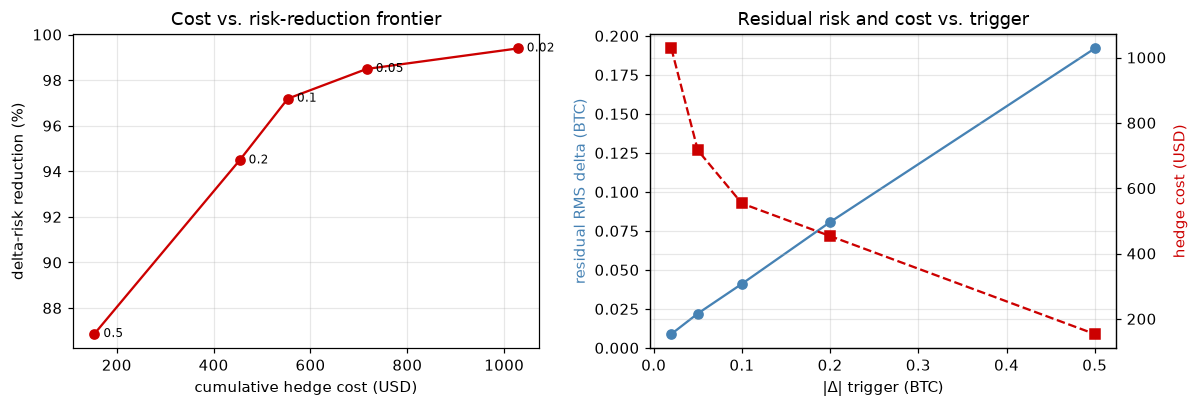

In [8]:
# Frontier: hedging cost vs. delta-risk reduction
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.plot(hed["hedge_cost"], hed["delta_risk_reduction"] * 100, "o-", color=WOLF)
for _, r in hed.iterrows():
    ax1.annotate(f"{r['threshold']:g}", (r["hedge_cost"], r["delta_risk_reduction"]*100),
                 textcoords="offset points", xytext=(6, -2), fontsize=8)
ax1.set_xlabel("cumulative hedge cost (USD)"); ax1.set_ylabel("delta-risk reduction (%)")
ax1.set_title("Cost vs. risk-reduction frontier")

ax2.plot(hed["threshold"], hed["rms_total_delta"], "o-", color="steelblue", label="residual RMS Δ")
ax2.set_xlabel("|Δ| trigger (BTC)"); ax2.set_ylabel("residual RMS delta (BTC)", color="steelblue")
ax2b = ax2.twinx()
ax2b.plot(hed["threshold"], hed["hedge_cost"], "s--", color=WOLF, label="hedge cost")
ax2b.set_ylabel("hedge cost (USD)", color=WOLF)
ax2.set_title("Residual risk and cost vs. trigger")
fig.tight_layout(); fig.savefig(FIG_DIR / "ps8_p5_cost_risk_frontier.png", bbox_inches="tight")
plt.show()

## 4 · The quoting / hedging interaction

Quoting and hedging are coupled: **the maker's fills drive the delta the hedger
must neutralize.** The panel below overlays, for the base 0.1-BTC run, (top) the
option book's net delta with the perp position that mirrors it, and (bottom) the
cumulative hedge cost against cumulative spread capture — the two P&L forces the
maker is trading off.

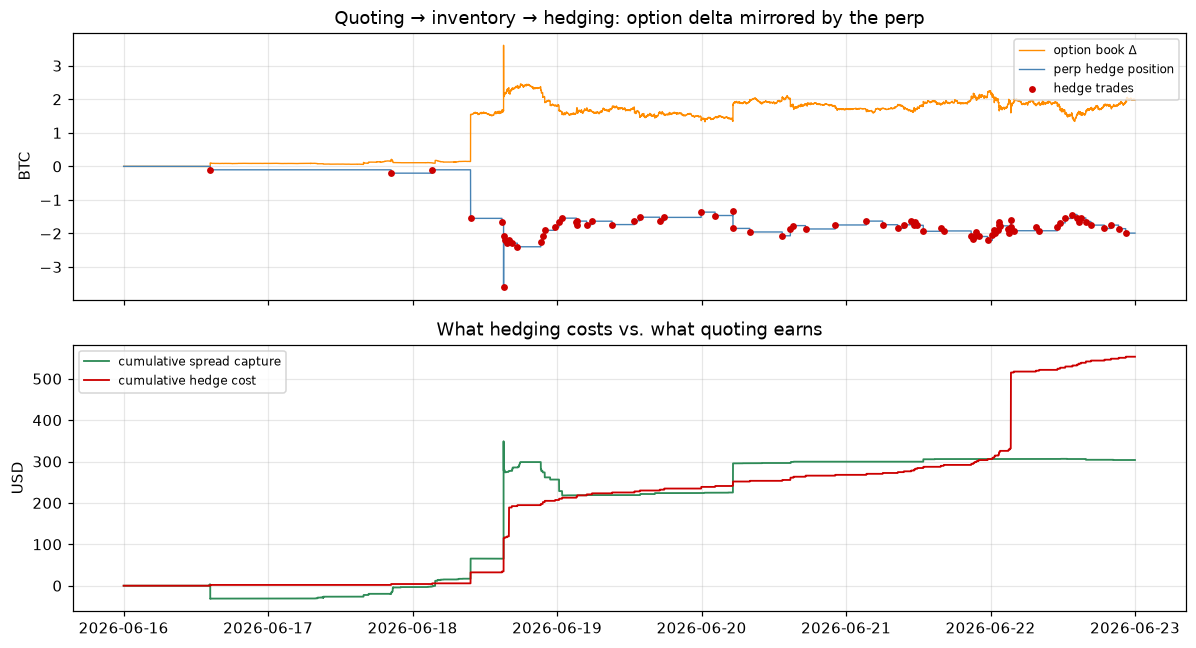

wrote output/ps8_p5_threshold_sweep.csv and output/ps8_p5_pnl_delta_timeseries.csv


In [9]:
fig, (axA, axB) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axA.plot(sb["ts"], sb["net_option_delta"], color="darkorange", lw=0.9, label="option book Δ")
axA.plot(sb["ts"], sb["perp"], color="steelblue", lw=0.9, label="perp hedge position")
hev = sb[sb["perp"].diff().fillna(0) != 0]
axA.scatter(hev["ts"], hev["perp"], s=12, color=WOLF, zorder=3, label="hedge trades")
axA.set_ylabel("BTC"); axA.legend(loc="upper right", fontsize=8)
axA.set_title("Quoting → inventory → hedging: option delta mirrored by the perp")

axB.plot(sb["ts"], sb["spread_pnl"], color="seagreen", lw=1.2, label="cumulative spread capture")
axB.plot(sb["ts"], sb["hedge_cost"], color=WOLF, lw=1.2, label="cumulative hedge cost")
axB.set_ylabel("USD"); axB.legend(loc="upper left", fontsize=8)
axB.set_title("What hedging costs vs. what quoting earns")
fig.tight_layout(); fig.savefig(FIG_DIR / "ps8_p5_hedge_events.png", bbox_inches="tight")
plt.show()

# persist the base-run time series for the record
keep = ["ts", "F", "net_option_delta", "perp", "total_delta", "equity",
        "spread_pnl", "inventory_pnl", "hedge_pnl", "hedge_cost", "is_fill"]
sb[keep].to_csv(OUT_DIR / "ps8_p5_pnl_delta_timeseries.csv", index=False)
print("wrote output/ps8_p5_threshold_sweep.csv and output/ps8_p5_pnl_delta_timeseries.csv")

## 5 · Conclusion

- **Risk reduction is real and large.** The 0.1-BTC threshold hedger cuts the
  option book's RMS net delta by **~97%** (≈1.5 → ≈0.04 BTC), and roughly halves
  max drawdown while lowering P&L volatility — exactly what a delta hedge is for.
- **Cost is monotonic in the trigger.** Tightening `|Δ|` from 0.5 → 0.02 BTC
  multiplies hedge count and perp turnover and raises cumulative hedge cost
  monotonically, for diminishing residual-risk gains — a clean cost-vs-risk
  frontier the desk can pick a point on.
- **Quoting and hedging are coupled.** The maker earns a spread edge but, on this
  thinly-traded weekly book, the frictions of holding delta near zero can rival or
  exceed that edge — so the *right* trigger is an economic choice, not `0` and not
  `∞`. A looser trigger keeps more of the spread P&L at the cost of carrying more
  directional risk between rebalances.
- **Engine integration.** The hedger runs *inside* the Week-5 event loop's
  mark-to-market and attribution structure; the spread / inventory / hedge / cost
  streams reconcile to total P&L to machine precision.

*Modelling notes.* Fills are the real trade tape with the maker on the passive
side; deltas are Black-76 forward deltas via PyTorch autograd (repo constraint);
option IV is inverted per strike from the top-of-book snapshots; the perp hedge
crosses the futures spread plus a 2.5-bps taker fee (`HedgeConfig.fee_bps`).